# 01 Simulating a single GBM price path | simulate_path()

A stochastic process $S_t$ follows GBM if it satisfies the SDE:

$$dS_t=\mu S_t dt + \sigma S_t \cdot dW_t$$

We implement the discrete geometric BM update rule, which is the solution to the SDE that models GBM:
$$S_{t+\Delta t} = S_t \cdot \exp((\mu-\sigma^2 / 2)t+\sigma W_t) $$
where $Z \sim \mathcal{N}(0,1)$ is drawn fresh at each step.
The $\sigma^2/2$ term is the Itô correction — without it the simulation would overestimate the average path.

In [1]:
import sys
sys.path.append('../src')
import numpy as np
import matplotlib.pyplot as plt
from gbm import simulate_path

## parameters

We use realistic values for a large-cap stock
- Sof0 = 100
- mu = 0.08 --> 8% expected return
- sigma = 0.20 --> 20% annual volatility
- T = 5.0 --> 5 year horizon
- N = 252 * T --> 252 * T trading days in T years

In [2]:
Sof0 = 100
mu = 0.08
sigma = 0.20
T = 5.0
N = int(252 * T)
path = simulate_path(Sof0, mu, sigma, T, N)
time = np.linspace(0, T, N+1)

## plotting

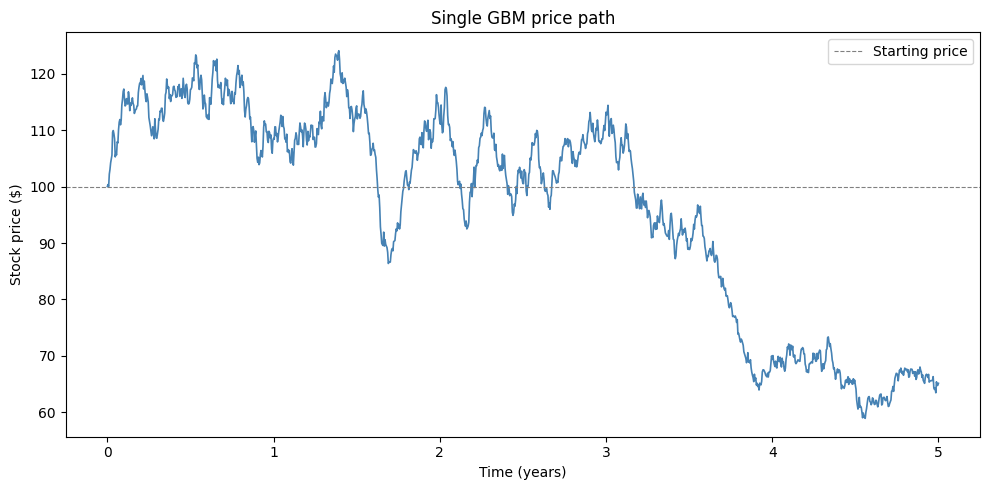

Starting price : $100.00
Final price    : $65.16
Return         : -34.8%


In [3]:
plt.figure(figsize=(10, 5))
plt.plot(time, path, color='steelblue', linewidth=1.2)
plt.axhline(Sof0, color='gray', linestyle='--', linewidth=0.8, label='Starting price')
plt.xlabel('Time (years)')
plt.ylabel('Stock price ($)')
plt.title('Single GBM price path')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Starting price : ${path[0]:.2f}")
print(f"Final price    : ${path[-1]:.2f}")
print(f"Return         : {(path[-1]/path[0] - 1)*100:.1f}%")